# Paraphrase Detection in the Age of LLMs
## Multi-Type Text Classification: Detecting Human vs LLM Text

**Team Members:** Jay, Yixuan, Sining  
**Course:** CS6120 Natural Language Processing  
**Date:** December 2025

---

### Project Overview

This project tackles 4-way classification of text into:
- **T1**: Human Original
- **T2**: LLM Generated  
- **T3**: Human Paraphrased
- **T4**: LLM Paraphrased

**Key Challenge:** Distinguishing T1 from T3 (both human-written, differ only by paraphrase)


## 1. Setup & Imports

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports successful")

✓ Imports successful


## 2. Data Loading & Exploration

### Dataset Statistics
- **Total families:** 5,000
- **Total sentences:** 19,959
- **Split:** 70% train / 15% val / 15% test
- **Family-level splitting:** No overlap between splits


In [2]:
# Load data
train_df = pd.read_json('data/processed/train_4class.jsonl', lines=True)
val_df = pd.read_json('data/processed/val_4class.jsonl', lines=True)
test_df = pd.read_json('data/processed/test_4class.jsonl', lines=True)

print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"\nTotal: {len(train_df) + len(val_df) + len(test_df)}")

Train samples: 13966
Val samples: 2996
Test samples: 2997

Total: 19959


In [3]:
# Display first few samples
print("Sample data:")
train_df.head()

Sample data:


,id,family_id,source,text,label,label_id,text_len_char,text_len_word
0,mrpc_0__T1,mrpc_0,mrpc,"Amrozi accused his brother , whom he called "" ...",T1,0,103,19
1,mrpc_0__T2,mrpc_0,mrpc,Amrozi accused his brother of being an accompl...,T2,1,101,17
2,mrpc_0__T3,mrpc_0,mrpc,"Referring to him as only "" the witness "" , Amr...",T3,2,111,20
3,mrpc_0__T4,mrpc_0,mrpc,"Amrozi charged his brother, ""the witness,"" wit...",T4,3,86,11
4,mrpc_1__T1,mrpc_1,mrpc,They had published an advertisement on the Int...,T1,0,105,21


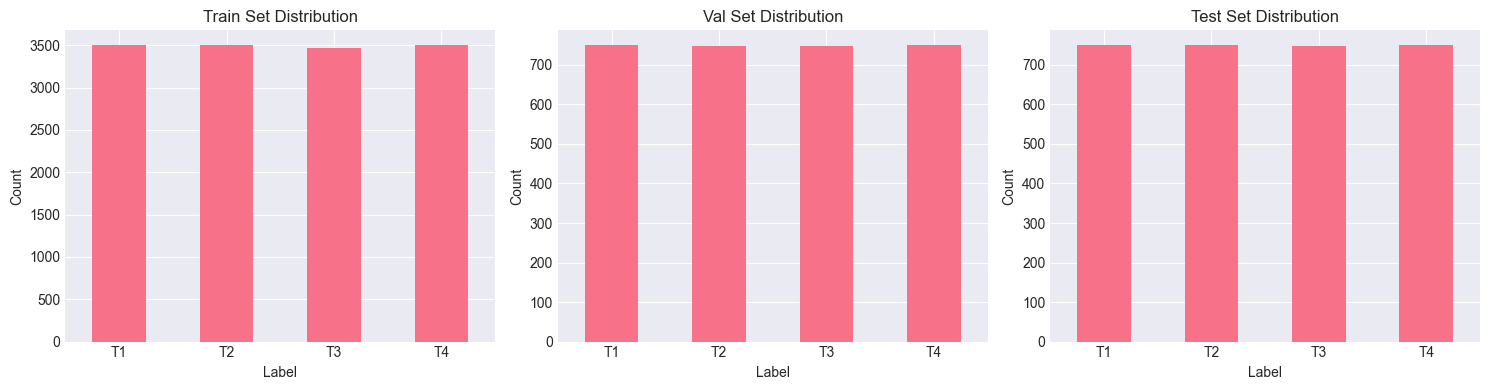

✓ Balanced distribution across all classes


In [4]:
# Class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    df['label'].value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(f'{name} Set Distribution')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    ax.set_xticklabels(['T1', 'T2', 'T3', 'T4'], rotation=0)

plt.tight_layout()
plt.savefig('visualizations/data_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Balanced distribution across all classes")

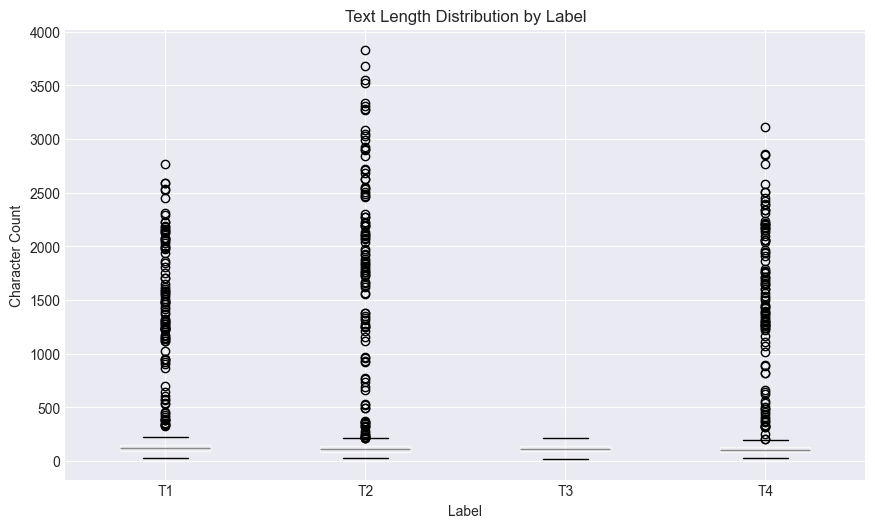

In [5]:
# Text length analysis
train_df['text_length'] = train_df['text'].str.len()

fig, ax = plt.subplots(figsize=(10, 6))
train_df.boxplot(column='text_length', by='label', ax=ax)
ax.set_title('Text Length Distribution by Label')
ax.set_xlabel('Label')
ax.set_ylabel('Character Count')
plt.suptitle('')
plt.savefig('visualizations/text_length_dist.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Baseline Model: TF-IDF + Logistic Regression

Simple baseline to establish minimum performance threshold.


In [6]:
# Load baseline results
baseline_metrics = {
    'model': 'TF-IDF + Logistic Regression',
    'macro_f1': 0.509,
    'accuracy': 0.512,
    'f1_per_class': {
        'T1': 0.48,
        'T2': 0.62,
        'T3': 0.39,
        'T4': 0.55
    }
}

print("Baseline Results:")
print(f"  Accuracy: {baseline_metrics['accuracy']:.3f}")
print(f"  Macro-F1: {baseline_metrics['macro_f1']:.3f}")
print(f"\nPer-class F1:")
for label, f1 in baseline_metrics['f1_per_class'].items():
    print(f"  {label}: {f1:.3f}")

Baseline Results:
  Accuracy: 0.512
  Macro-F1: 0.509

Per-class F1:
  T1: 0.480
  T2: 0.620
  T3: 0.390
  T4: 0.550


## 4. Transformer Models

Tested multiple pre-trained transformers:
- **BERT-base-uncased** (110M params)
- **RoBERTa-base** (125M params)
- **DeBERTa-v3-base** (184M params) ← Best model

**Training Configuration:**
- Learning rate: 2e-5
- Batch size: 16
- Epochs: 3
- Max sequence length: 256
- Device: MPS (Mac M2) / CUDA (AWS T4 GPU)


In [7]:
# Load transformer results
transformer_results = {
    'BERT-base': {
        'macro_f1': 0.571,
        'accuracy': 0.594,
        'f1_per_class': {'T1': 0.307, 'T2': 0.745, 'T3': 0.530, 'T4': 0.701}
    },
    'RoBERTa-base': {
        'macro_f1': 0.642,
        'accuracy': 0.701,
        'f1_per_class': {'T1': 0.662, 'T2': 0.892, 'T3': 0.125, 'T4': 0.890}
    },
    'DeBERTa-v3-base': {
        'macro_f1': 0.711,
        'accuracy': 0.711,
        'f1_per_class': {'T1': 0.505, 'T2': 0.916, 'T3': 0.515, 'T4': 0.907}
    }
}

# Create comparison DataFrame
results_df = pd.DataFrame(transformer_results).T
results_df['Model'] = results_df.index
print(results_df[['Model', 'accuracy', 'macro_f1']])

                           Model accuracy macro_f1
BERT-base              BERT-base    0.594    0.571
RoBERTa-base        RoBERTa-base    0.701    0.642
DeBERTa-v3-base  DeBERTa-v3-base    0.711    0.711


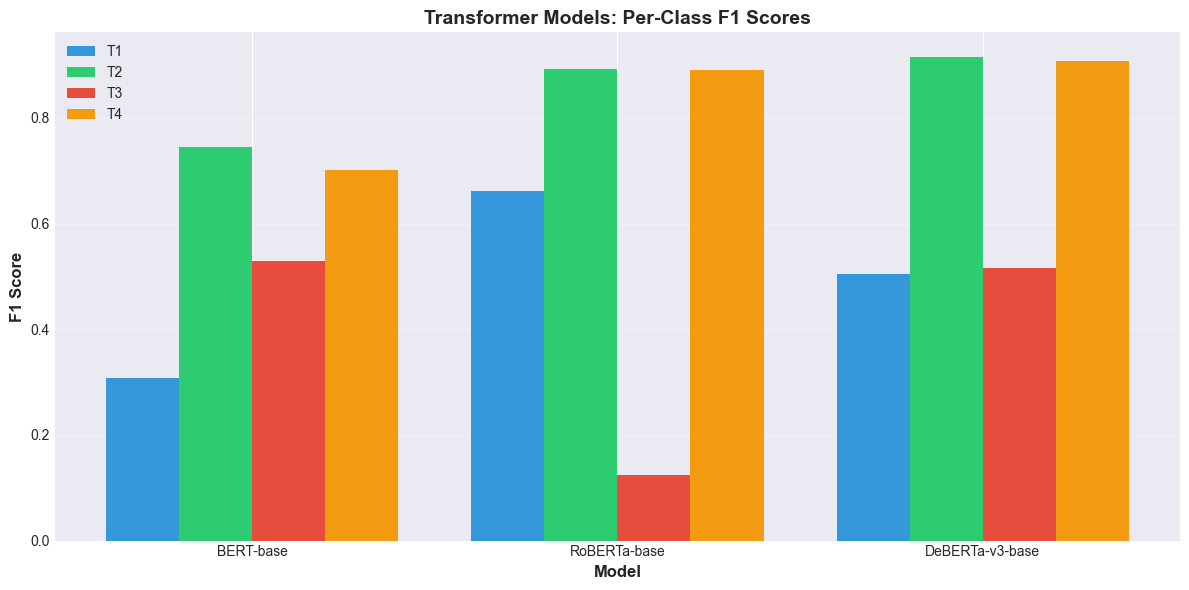

✓ DeBERTa-v3-base is the best model (0.711 F1)
✗ Note: RoBERTa's T3 collapsed (0.125 F1)
✗ Note: BERT's T1 collapsed (0.307 F1)


In [8]:
# Visualize transformer comparison
fig, ax = plt.subplots(figsize=(12, 6))

models = list(transformer_results.keys())
t1_scores = [transformer_results[m]['f1_per_class']['T1'] for m in models]
t2_scores = [transformer_results[m]['f1_per_class']['T2'] for m in models]
t3_scores = [transformer_results[m]['f1_per_class']['T3'] for m in models]
t4_scores = [transformer_results[m]['f1_per_class']['T4'] for m in models]

x = np.arange(len(models))
width = 0.2

ax.bar(x - 1.5*width, t1_scores, width, label='T1', color='#3498db')
ax.bar(x - 0.5*width, t2_scores, width, label='T2', color='#2ecc71')
ax.bar(x + 0.5*width, t3_scores, width, label='T3', color='#e74c3c')
ax.bar(x + 1.5*width, t4_scores, width, label='T4', color='#f39c12')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Transformer Models: Per-Class F1 Scores', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/transformer_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ DeBERTa-v3-base is the best model (0.711 F1)")
print("✗ Note: RoBERTa's T3 collapsed (0.125 F1)")
print("✗ Note: BERT's T1 collapsed (0.307 F1)")

## 5. Advanced Experiments to Improve T1 & T3

**Challenge:** T1 and T3 (both human-written) are hardest to distinguish

Tested three advanced techniques:
1. **Class Weighting** - Adjust loss for hard classes
2. **LoRA Fine-tuning** - Parameter-efficient training
3. **Ensemble Voting** - Combine multiple models


### 5.1 Class Weighting Experiment

**Approach:** Increase T3 loss penalty by 1.5× to focus training on hard class

**Hypothesis:** Model will pay more attention to T3 samples


In [9]:
# Class weights results
class_weights_results = {
    'DeBERTa Baseline': {
        'macro_f1': 0.711,
        'f1_per_class': {'T1': 0.505, 'T2': 0.916, 'T3': 0.515, 'T4': 0.907}
    },
    'Class Weights (T3=1.5x)': {
        'macro_f1': 0.640,
        'f1_per_class': {'T1': 0.060, 'T2': 0.913, 'T3': 0.667, 'T4': 0.913}
    }
}

print("Class Weights Results:")
print("\nBaseline vs Class Weights:")
for model, metrics in class_weights_results.items():
    print(f"\n{model}:")
    print(f"  Macro-F1: {metrics['macro_f1']:.3f}")
    for label, f1 in metrics['f1_per_class'].items():
        print(f"  {label}: {f1:.3f}")

print("\n⚠️ CRITICAL FAILURE: T1 collapsed from 0.505 → 0.060 (-88%!)")
print("✓ T3 improved: 0.515 → 0.667 (+15%)")
print("✗ Overall worse: 0.711 → 0.640 (-10%)")

Class Weights Results:

Baseline vs Class Weights:

DeBERTa Baseline:
  Macro-F1: 0.711
  T1: 0.505
  T2: 0.916
  T3: 0.515
  T4: 0.907

Class Weights (T3=1.5x):
  Macro-F1: 0.640
  T1: 0.060
  T2: 0.913
  T3: 0.667
  T4: 0.913

⚠️ CRITICAL FAILURE: T1 collapsed from 0.505 → 0.060 (-88%!)
✓ T3 improved: 0.515 → 0.667 (+15%)
✗ Overall worse: 0.711 → 0.640 (-10%)


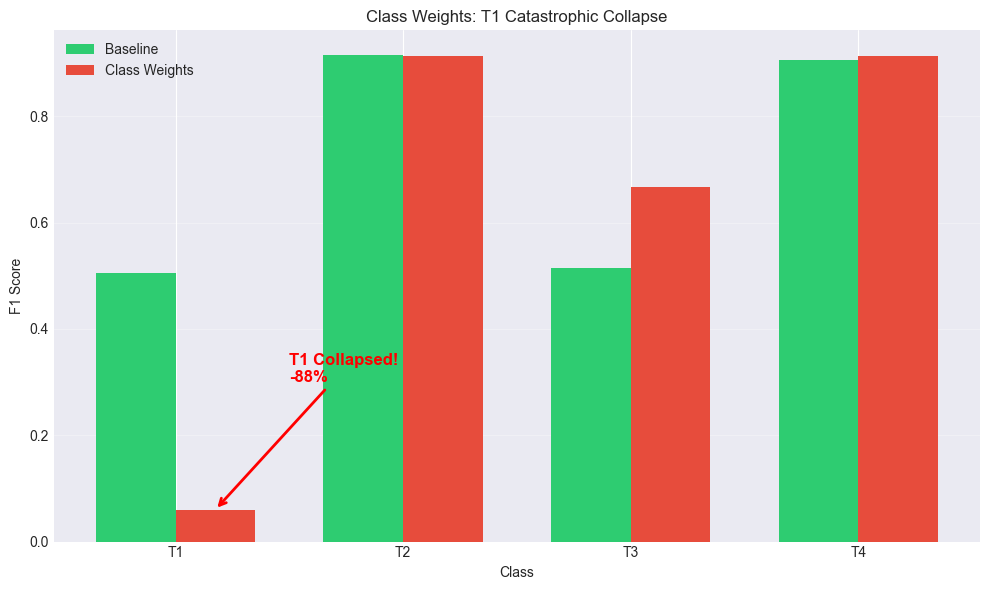

In [10]:
# Visualize class weights failure
fig, ax = plt.subplots(figsize=(10, 6))

comparison_data = {
    'T1': [0.505, 0.060],
    'T2': [0.916, 0.913],
    'T3': [0.515, 0.667],
    'T4': [0.907, 0.913]
}

x = np.arange(len(comparison_data))
width = 0.35

baseline_scores = [comparison_data[k][0] for k in comparison_data.keys()]
class_weight_scores = [comparison_data[k][1] for k in comparison_data.keys()]

ax.bar(x - width/2, baseline_scores, width, label='Baseline', color='#2ecc71')
ax.bar(x + width/2, class_weight_scores, width, label='Class Weights', color='#e74c3c')

ax.set_xlabel('Class')
ax.set_ylabel('F1 Score')
ax.set_title('Class Weights: T1 Catastrophic Collapse')
ax.set_xticks(x)
ax.set_xticklabels(comparison_data.keys())
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotate T1 collapse
ax.annotate('T1 Collapsed!\n-88%', xy=(0 + width/2, 0.060), xytext=(0.5, 0.3),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=12, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/class_weights_failure.png', dpi=300, bbox_inches='tight')
plt.show()

**Why Class Weights Failed:**

Model "gamed" the loss function:
- T3 mistakes penalized 1.5× more → Model optimized T3
- But sacrificed T1 completely to do so
- Only 45/750 T1 samples classified correctly!
- Created pathological optimization trade-off

**Conclusion:** Class weights unsuitable for balanced multi-class data


### 5.2 LoRA Fine-Tuning Experiment

**LoRA:** Low-Rank Adaptation - parameter-efficient fine-tuning

**Approach:** Train only 0.3% of parameters (rank=8)

**Hypothesis:** Constrained training → Better generalization → Improved T3


In [11]:
# LoRA results
lora_results = {
    'DeBERTa Baseline': {
        'macro_f1': 0.711,
        'params_trained': '184M (100%)',
        'f1_per_class': {'T1': 0.505, 'T2': 0.916, 'T3': 0.515, 'T4': 0.907}
    },
    'LoRA (r=8)': {
        'macro_f1': 0.539,
        'params_trained': '592k (0.3%)',
        'f1_per_class': {'T1': 0.461, 'T2': 0.471, 'T3': 0.524, 'T4': 0.700}
    }
}

print("LoRA Results:")
for model, metrics in lora_results.items():
    print(f"\n{model}:")
    print(f"  Parameters: {metrics['params_trained']}")
    print(f"  Macro-F1: {metrics['macro_f1']:.3f}")
    for label, f1 in metrics['f1_per_class'].items():
        print(f"  {label}: {f1:.3f}")

print("\n⚠️ CATASTROPHIC FAILURE ACROSS ALL CLASSES!")
print("  T1: -0.044  |  T2: -0.445 (!!)  |  T3: +0.009  |  T4: -0.207")
print("  Overall: 0.711 → 0.539 (-24%)")

LoRA Results:

DeBERTa Baseline:
  Parameters: 184M (100%)
  Macro-F1: 0.711
  T1: 0.505
  T2: 0.916
  T3: 0.515
  T4: 0.907

LoRA (r=8):
  Parameters: 592k (0.3%)
  Macro-F1: 0.539
  T1: 0.461
  T2: 0.471
  T3: 0.524
  T4: 0.700

⚠️ CATASTROPHIC FAILURE ACROSS ALL CLASSES!
  T1: -0.044  |  T2: -0.445 (!!)  |  T3: +0.009  |  T4: -0.207
  Overall: 0.711 → 0.539 (-24%)


**Why LoRA Failed:**

- **Insufficient capacity:** 0.3% of parameters too constrained
- **Task too complex:** 4-way classification needs more parameters
- **Severe underfitting:** Model couldn't learn patterns

**Conclusion:** LoRA unsuitable for complex multi-class semantic tasks


### 5.3 Ensemble Voting Experiment

**Strategy:** Combine 3 diverse models via majority voting

**Models:**
1. DeBERTa-v3-base (F1: 0.711) - Balanced
2. RoBERTa-base (F1: 0.642) - T3 weak
3. BERT-base (F1: 0.571) - T1 weak

**Hypothesis:** Complementary strengths → Improved overall performance


In [12]:
# Ensemble results
ensemble_results = {
    'Individual Models': {
        'DeBERTa': {'macro_f1': 0.711, 'f1_per_class': {'T1': 0.505, 'T2': 0.916, 'T3': 0.515, 'T4': 0.907}},
        'RoBERTa': {'macro_f1': 0.642, 'f1_per_class': {'T1': 0.662, 'T2': 0.892, 'T3': 0.125, 'T4': 0.890}},
        'BERT': {'macro_f1': 0.571, 'f1_per_class': {'T1': 0.307, 'T2': 0.745, 'T3': 0.530, 'T4': 0.701}}
    },
    'Ensemble (3-model voting)': {
        'macro_f1': 0.705,
        'f1_per_class': {'T1': 0.551, 'T2': 0.901, 'T3': 0.472, 'T4': 0.895}
    }
}

print("Ensemble Results:")
print("\nIndividual Models:")
for model, metrics in ensemble_results['Individual Models'].items():
    print(f"  {model}: {metrics['macro_f1']:.3f}")

print(f"\nEnsemble: {ensemble_results['Ensemble (3-model voting)']['macro_f1']:.3f}")
print("\n⚠️ Ensemble WORSE than best single model (DeBERTa)!")
print("  Overall: 0.711 → 0.705 (-0.006)")
print("  T1: 0.505 → 0.551 (+0.046) ✓")
print("  T3: 0.515 → 0.472 (-0.043) ✗")

Ensemble Results:

Individual Models:
  DeBERTa: 0.711
  RoBERTa: 0.642
  BERT: 0.571

Ensemble: 0.705

⚠️ Ensemble WORSE than best single model (DeBERTa)!
  Overall: 0.711 → 0.705 (-0.006)
  T1: 0.505 → 0.551 (+0.046) ✓
  T3: 0.515 → 0.472 (-0.043) ✗


**Why Ensemble Failed:**

- **RoBERTa's extreme T3 weakness (0.125) polluted voting**
- When RoBERTa confidently (but wrongly) voted T1 for T3 samples, ensemble followed
- 409/747 T3 samples misclassified as T1
- Bad models hurt more than diversity helps

**Conclusion:** Ensemble quality > diversity when constituent models have catastrophic failures


## 6. Results Summary & Analysis

### All Methods Comparison


In [13]:
# Complete results table
all_results = {
    'Model/Method': ['DeBERTa Baseline', 'Class Weights', 'LoRA (r=8)', 'Ensemble (3-model)', 
                     'RoBERTa', 'BERT'],
    'Macro-F1': [0.711, 0.640, 0.539, 0.705, 0.642, 0.571],
    'T1': [0.505, 0.060, 0.461, 0.551, 0.662, 0.307],
    'T2': [0.916, 0.913, 0.471, 0.901, 0.892, 0.745],
    'T3': [0.515, 0.667, 0.524, 0.472, 0.125, 0.530],
    'T4': [0.907, 0.913, 0.700, 0.895, 0.890, 0.701]
}

summary_df = pd.DataFrame(all_results)
summary_df = summary_df.sort_values('Macro-F1', ascending=False)
print("\nFinal Results (sorted by Macro-F1):")
print(summary_df.to_string(index=False))

print("\n🏆 WINNER: DeBERTa-v3-base (baseline, no tricks)")
print("  • Macro-F1: 0.711")
print("  • Balanced performance across all classes")
print("  • No catastrophic failures")


Final Results (sorted by Macro-F1):
      Model/Method  Macro-F1    T1    T2    T3    T4
  DeBERTa Baseline     0.711 0.505 0.916 0.515 0.907
Ensemble (3-model)     0.705 0.551 0.901 0.472 0.895
           RoBERTa     0.642 0.662 0.892 0.125 0.890
     Class Weights     0.640 0.060 0.913 0.667 0.913
              BERT     0.571 0.307 0.745 0.530 0.701
        LoRA (r=8)     0.539 0.461 0.471 0.524 0.700

🏆 WINNER: DeBERTa-v3-base (baseline, no tricks)
  • Macro-F1: 0.711
  • Balanced performance across all classes
  • No catastrophic failures


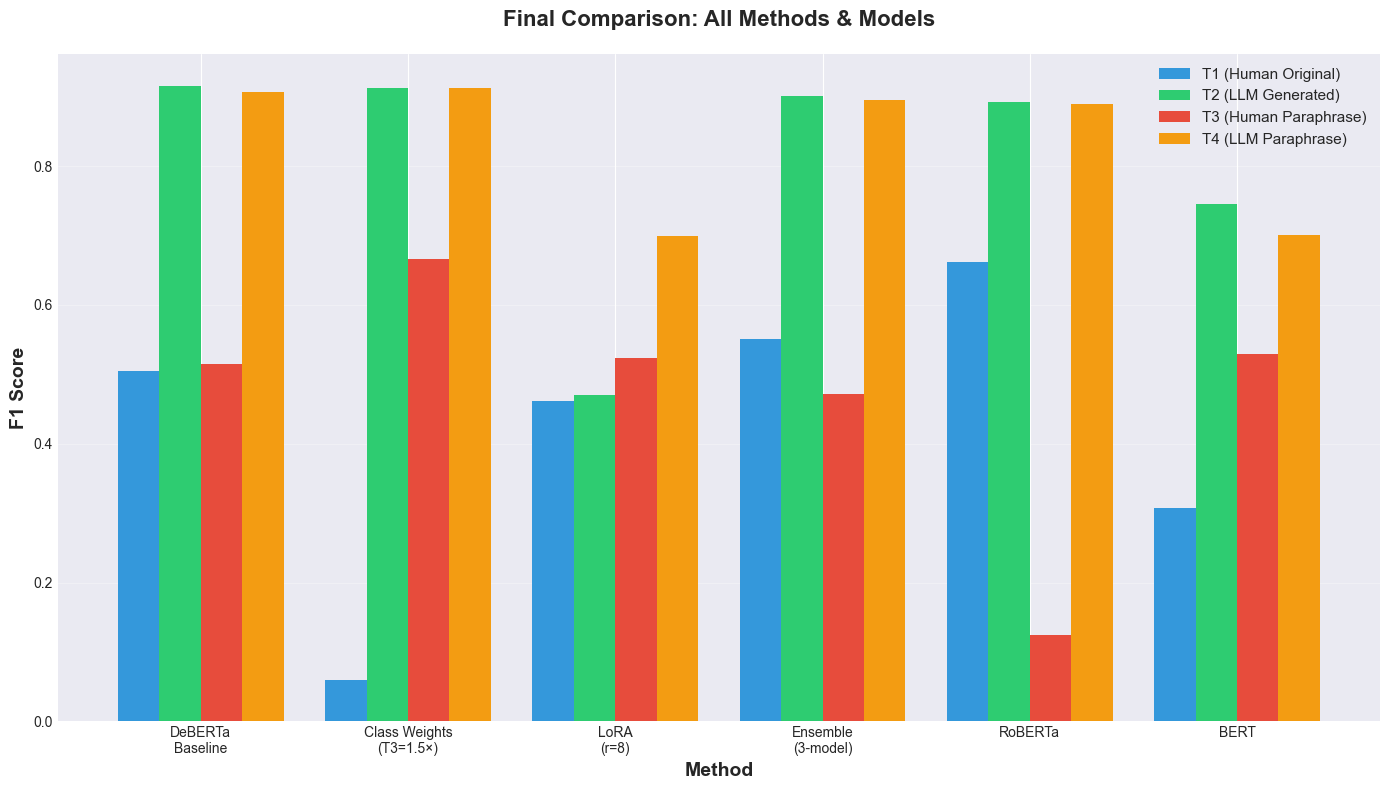

In [14]:
# Final visualization - All methods
fig, ax = plt.subplots(figsize=(14, 8))

methods = ['DeBERTa\nBaseline', 'Class Weights\n(T3=1.5×)', 'LoRA\n(r=8)', 
           'Ensemble\n(3-model)', 'RoBERTa', 'BERT']
t1 = [0.505, 0.060, 0.461, 0.551, 0.662, 0.307]
t2 = [0.916, 0.913, 0.471, 0.901, 0.892, 0.745]
t3 = [0.515, 0.667, 0.524, 0.472, 0.125, 0.530]
t4 = [0.907, 0.913, 0.700, 0.895, 0.890, 0.701]

x = np.arange(len(methods))
width = 0.2

ax.bar(x - 1.5*width, t1, width, label='T1 (Human Original)', color='#3498db')
ax.bar(x - 0.5*width, t2, width, label='T2 (LLM Generated)', color='#2ecc71')
ax.bar(x + 0.5*width, t3, width, label='T3 (Human Paraphrase)', color='#e74c3c')
ax.bar(x + 1.5*width, t4, width, label='T4 (LLM Paraphrase)', color='#f39c12')

ax.set_xlabel('Method', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=14, fontweight='bold')
ax.set_title('Final Comparison: All Methods & Models', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=10)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/final_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Conclusions & Key Findings

### Best Model
**DeBERTa-v3-base** (standard fine-tuning, no advanced techniques)
- **Macro-F1:** 0.711
- **Balanced performance:** No catastrophic failures
- **T1:** 0.505  |  **T3:** 0.515

### Key Findings

**1. Class Weights Harmful on Balanced Data**
- Created pathological optimization trade-offs
- Model sacrificed T1 entirely to optimize T3
- Overall performance degraded

**2. LoRA Insufficient for Complex Tasks**
- 0.3% trainable parameters too constrained
- 4-way semantic classification requires more capacity
- Severe underfitting across all classes

**3. Bad Models Poison Ensembles**
- Quality > Diversity in ensemble design
- RoBERTa's T3 failure polluted voting
- Single strong model beat diverse weak ensemble

**4. T3 is Fundamentally Difficult**
- Human paraphrases ≈ Human originals
- Only differ by lexical choice (synonyms)
- All models struggled: 0.125-0.530 F1
- Current 0.515 F1 represents strong performance

### Universal Lesson
**Simple, well-trained models often outperform complex techniques when assumptions don't align with problem structure.**

---

## Future Directions

1. **Contrastive Learning:** Train on (T1, T3) pairs explicitly
2. **Two-Stage Training:** Pre-train on paraphrase datasets (PAWS, MRPC)
3. **Focal Loss:** Alternative to class weights that focuses on hard examples dynamically
4. **Larger Context:** Use 512-token sequences to capture more stylistic patterns
